### You are going to classify 5 types of flowers, i.e: tulips, sunflowers, roses, dandelions and daisies. You will try to apply convolutional neural network architecture (CNN) and transfer learning. Think, which one of them could be better and why likewise memorize the details what is the receipt of writting a code.


Firstly, you have to upload the zip file with the data

In [1]:
# Dataset available locally

Unzip the dataset which contains the flower dataset

In [2]:
import os
classes = sorted([d for d in os.listdir('./flower_photos') if os.path.isdir(os.path.join('./flower_photos', d))])
print(f"Classes: {classes}")


Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Prepare datasets

Train datset size: 480
Test datset size: 120
Number of classes: 5


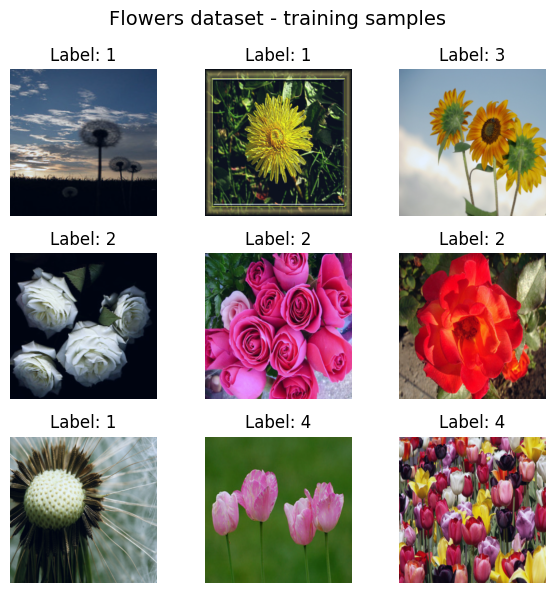

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


dataset_path = './flower_photos'

# Prepare train and test image transforms
train_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((256, 256)),
    v2.RandomHorizontalFlip(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((256, 256)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset instances
train_dataset_full = ImageFolder(dataset_path, transform=train_transform)
test_dataset_full = ImageFolder(dataset_path, transform=test_transform)

# Train and test dataset split
indices = np.arange(len(train_dataset_full))
train_set_indices, test_set_indices = train_test_split(indices, test_size=0.2)
train_dataset = Subset(train_dataset_full, train_set_indices)
test_dataset = Subset(test_dataset_full, test_set_indices)

num_classes = len(train_dataset_full.classes)

print(f"Train datset size: {len(train_dataset)}")
print(f"Test datset size: {len(test_dataset)}")
print(f"Number of classes: {num_classes}")

# ----------------------------------------------------------------------------------------------------------------------
# Plot the first 9 images from the train set
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
fig.suptitle("Flowers dataset - training samples", fontsize=14)

for i in range(9):
    image, label = train_dataset[i]
    image = image.squeeze().permute(1, 2, 0).numpy()

    # Normalize to 0-1 range (this is optional and offers better visualization, pyplot expects the 0-1 range for float dtypes)
    image = image - np.min(image)
    image = image / np.max(image)

    ax = axes[i // 3, i % 3]
    ax.imshow(image)
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()
# ----------------------------------------------------------------------------------------------------------------------

# Create dataloader instances
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [4]:
# Function for model evaluation on the test subset.
def test(model, loss_func, test_loader, device):
    model.eval()
    test_losses = []
    test_preds = []
    test_gt = []

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = model(inputs)
        loss = loss_func(logits, labels)
        test_losses.append(loss.item())

        pred = torch.argmax(logits, dim=1)
        test_preds.extend(pred.cpu().numpy())
        test_gt.extend(labels.detach().cpu().numpy())

    test_loss = sum(test_losses) / len(test_losses)
    test_acc = accuracy_score(test_gt, test_preds)

    model.train()

    return test_loss, test_acc

### Fully connected neural network

torch.Size([32, 5])
Using device: mps
Initial test accuracy: 0.2333, test loss: 1.6022
Epoch: 0, train loss: 4.2883, train acc: 0.3250, test loss: 5.6601, test_acc: 0.2333
Epoch: 1, train loss: 2.7831, train acc: 0.4417, test loss: 2.3769, test_acc: 0.4000
Epoch: 2, train loss: 1.6594, train acc: 0.5542, test loss: 2.1106, test_acc: 0.4583
Epoch: 3, train loss: 1.1837, train acc: 0.6000, test loss: 1.7626, test_acc: 0.4333
Epoch: 4, train loss: 0.8714, train acc: 0.7125, test loss: 2.0623, test_acc: 0.4583
Epoch: 5, train loss: 0.6206, train acc: 0.8063, test loss: 1.8772, test_acc: 0.4417
Epoch: 6, train loss: 0.4165, train acc: 0.8583, test loss: 2.0661, test_acc: 0.4583
Epoch: 7, train loss: 0.4083, train acc: 0.8771, test loss: 2.0695, test_acc: 0.5000
Epoch: 8, train loss: 0.3339, train acc: 0.8896, test loss: 2.5741, test_acc: 0.4417
Epoch: 9, train loss: 0.3531, train acc: 0.8875, test loss: 2.5306, test_acc: 0.4167
Epoch: 10, train loss: 0.3547, train acc: 0.9000, test loss: 2.

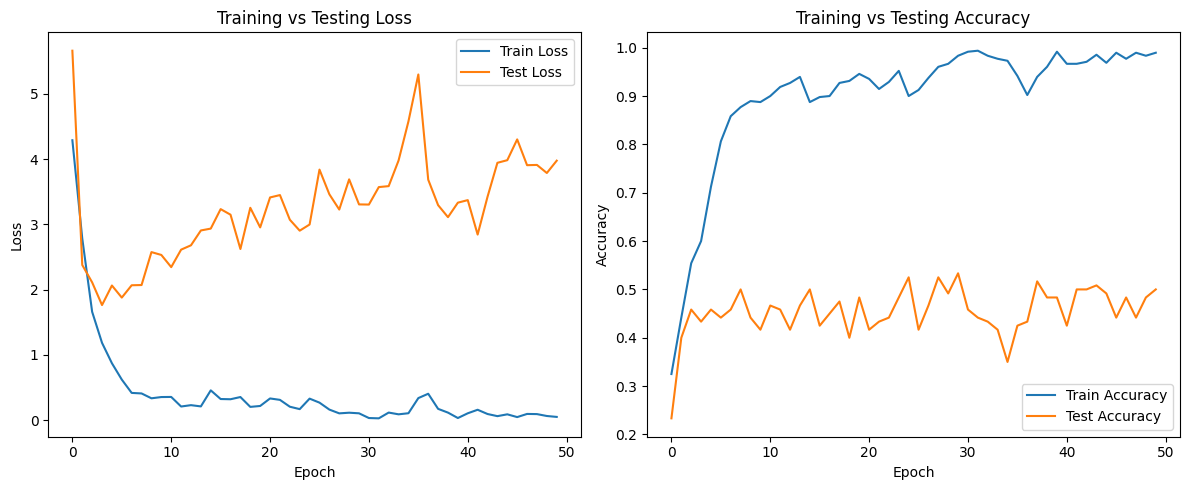

In [5]:
# Create model instance
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=3*256*256, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=num_classes),
)


# Test the model with a random batch (optional)
rand_input = torch.randn(32, 3, 256, 256)
rand_out = model(rand_input)
print(rand_out.shape)

# breakpoint()

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Move model to GPU (if available)
model.to(device)

# Prepare a loss function
loss_func = nn.CrossEntropyLoss()

# Create new optimizer instance
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Define total number of epochs
num_epochs = 50

# Calculate the initial model loss and accuracy
test_loss, test_acc = test(model, loss_func, test_loader, device)
print(f"Initial test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

# Prepare lists for accuracies and losses tracking
all_train_losses = []
all_train_acc = []
all_test_losses = []
all_test_acc = []

# Start training
for epoch in range(num_epochs):
    preds = []
    losses = []
    gt = []

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = loss_func(logits, labels)
        loss.backward()
        optimizer.step()

        p = torch.argmax(logits, dim=1)
        preds.extend(p.cpu().numpy())
        losses.append(loss.item())
        gt.extend(labels.detach().cpu().numpy())

    test_loss, test_acc = test(model, loss_func, test_loader, device)
    train_loss = sum(losses) / len(losses)
    train_acc = accuracy_score(gt, preds)

    print(f"Epoch: {epoch}, train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

    all_train_losses.append(train_loss)
    all_train_acc.append(train_acc)
    all_test_losses.append(test_loss)
    all_test_acc.append(test_acc)

epochs = list(range(len(all_train_losses)))

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
sns.lineplot(x=epochs, y=all_train_losses, label='Train Loss')
sns.lineplot(x=epochs, y=all_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Testing Loss')

# Accuracy plot
plt.subplot(1, 2, 2)
sns.lineplot(x=epochs, y=all_train_acc, label='Train Accuracy')
sns.lineplot(x=epochs, y=all_test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')

plt.tight_layout()
plt.show()

### Define a custom neural network model

In [6]:
class MyCustomModel(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()

        self.cnn_backbone = nn.Sequential(
            # Layer 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Layer 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.AdaptiveAvgPool2d((2, 2)),
            # Vectorize 2D feature maps
            nn.Flatten(),
        )

        self.classifier_head = nn.Sequential(
            nn.Linear(in_features=256*2*2, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=num_classes)
        )

    def forward(self, x):
        x = self.cnn_backbone(x)
        # breakpoint()
        # return x
        return self.classifier_head(x)

## Custom CNN model training (from scratch)

torch.Size([32, 5])
Using device: mps
Initial test accuracy: 0.1500, test loss: 1.6111
Epoch: 0, train loss: 1.6212, train acc: 0.2125, test loss: 1.6104, test_acc: 0.1500
Epoch: 1, train loss: 1.5265, train acc: 0.2167, test loss: 1.4843, test_acc: 0.1667
Epoch: 2, train loss: 1.3301, train acc: 0.3583, test loss: 1.3682, test_acc: 0.3417
Epoch: 3, train loss: 1.2995, train acc: 0.4000, test loss: 1.3616, test_acc: 0.4250
Epoch: 4, train loss: 1.2208, train acc: 0.4000, test loss: 1.2385, test_acc: 0.5167
Epoch: 5, train loss: 1.1648, train acc: 0.4771, test loss: 1.1821, test_acc: 0.4167
Epoch: 6, train loss: 1.1195, train acc: 0.5271, test loss: 1.1536, test_acc: 0.3917
Epoch: 7, train loss: 1.0223, train acc: 0.5687, test loss: 1.2318, test_acc: 0.4333
Epoch: 8, train loss: 1.0606, train acc: 0.5479, test loss: 1.1131, test_acc: 0.5583
Epoch: 9, train loss: 0.9689, train acc: 0.5875, test loss: 1.0746, test_acc: 0.5083
Epoch: 10, train loss: 0.9275, train acc: 0.5938, test loss: 1.

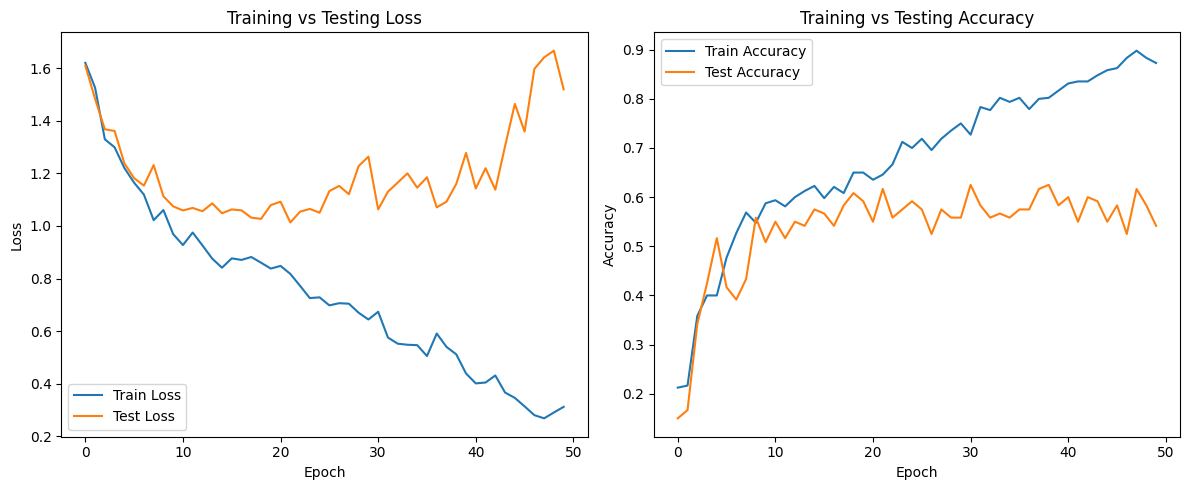

In [7]:
# Create model instance
model = MyCustomModel(num_classes)

# Test the model with a random batch (optional)
rand_input = torch.randn((32, 3, 256, 256))
rand_out = model(rand_input)
print(rand_out.shape)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Move model to GPU (if available)
model.to(device)

# Prepare a loss function
loss_func = nn.CrossEntropyLoss()

# Create new optimizer instance
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Define total number of epochs
num_epochs = 50

# Calculate the initial model loss and accuracy
test_loss, test_acc = test(model, loss_func, test_loader, device)
print(f"Initial test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

# Prepare lists for accuracies and losses tracking
all_train_losses = []
all_train_acc = []
all_test_losses = []
all_test_acc = []

# Start training
for epoch in range(num_epochs):
    preds = []
    losses = []
    gt = []

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = loss_func(logits, labels)
        loss.backward()
        optimizer.step()

        p = torch.argmax(logits, dim=1)
        preds.extend(p.cpu().numpy())
        losses.append(loss.item())
        gt.extend(labels.detach().cpu().numpy())

    test_loss, test_acc = test(model, loss_func, test_loader, device)
    train_loss = sum(losses) / len(losses)
    train_acc = accuracy_score(gt, preds)

    print(f"Epoch: {epoch}, train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

    all_train_losses.append(train_loss)
    all_train_acc.append(train_acc)
    all_test_losses.append(test_loss)
    all_test_acc.append(test_acc)

epochs = list(range(len(all_train_losses)))

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
sns.lineplot(x=epochs, y=all_train_losses, label='Train Loss')
sns.lineplot(x=epochs, y=all_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Testing Loss')

# Accuracy plot
plt.subplot(1, 2, 2)
sns.lineplot(x=epochs, y=all_train_acc, label='Train Accuracy')
sns.lineplot(x=epochs, y=all_test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')

plt.tight_layout()
plt.show()

### Save model weights

In [8]:
torch.save(model.state_dict(), "model_weights.pth")

### Visualize feature maps

MyCustomModel(
  (cnn_backbone): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): AdaptiveAvgPool2d(output_size=(2, 2))
    (17): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier_head): Sequential(
    (0): Linear(in_features

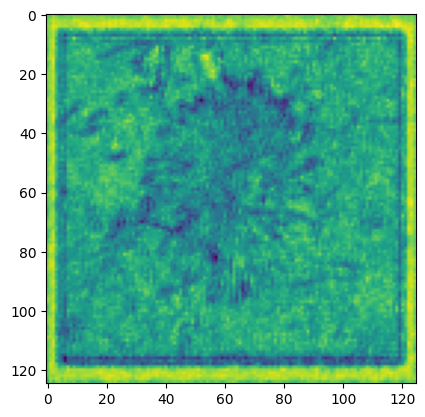

(64, 125, 125)


In [9]:
activations = []

def save_activation_hook(module, input, output):
    activations.append(output.cpu().detach().numpy())

print(model)

model.cnn_backbone[4].register_forward_hook(save_activation_hook)
img, label = train_dataset[1]

img = img.unsqueeze(0) # Add batch dimension
img = img.to(device)
out = model(img)

plt.imshow(activations[0][0][0])
plt.show()

print(activations[0][0].shape)


## Transfer learning

### Prepare a pretrained model

In [10]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Update the classifier head

In [11]:
head_in_features = model.fc.in_features
model.fc = nn.Linear(head_in_features, num_classes)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

torch.Size([32, 5])
Using device: mps
Pretrained model test accuracy: 0.1833, test loss: 1.7481
Epoch: 0, train loss: 0.8313, train acc: 0.6896, test loss: 0.4954, test_acc: 0.8167
Epoch: 1, train loss: 0.1471, train acc: 0.9771, test loss: 0.2777, test_acc: 0.9083
Epoch: 2, train loss: 0.0499, train acc: 0.9979, test loss: 0.2180, test_acc: 0.9167
Epoch: 3, train loss: 0.0284, train acc: 1.0000, test loss: 0.2138, test_acc: 0.9167
Epoch: 4, train loss: 0.0182, train acc: 1.0000, test loss: 0.1993, test_acc: 0.9167
Epoch: 5, train loss: 0.0149, train acc: 1.0000, test loss: 0.1910, test_acc: 0.9167
Epoch: 6, train loss: 0.0124, train acc: 1.0000, test loss: 0.1982, test_acc: 0.9333
Epoch: 7, train loss: 0.0059, train acc: 1.0000, test loss: 0.1944, test_acc: 0.9167
Epoch: 8, train loss: 0.0066, train acc: 1.0000, test loss: 0.1810, test_acc: 0.9333
Epoch: 9, train loss: 0.0051, train acc: 1.0000, test loss: 0.1827, test_acc: 0.9417


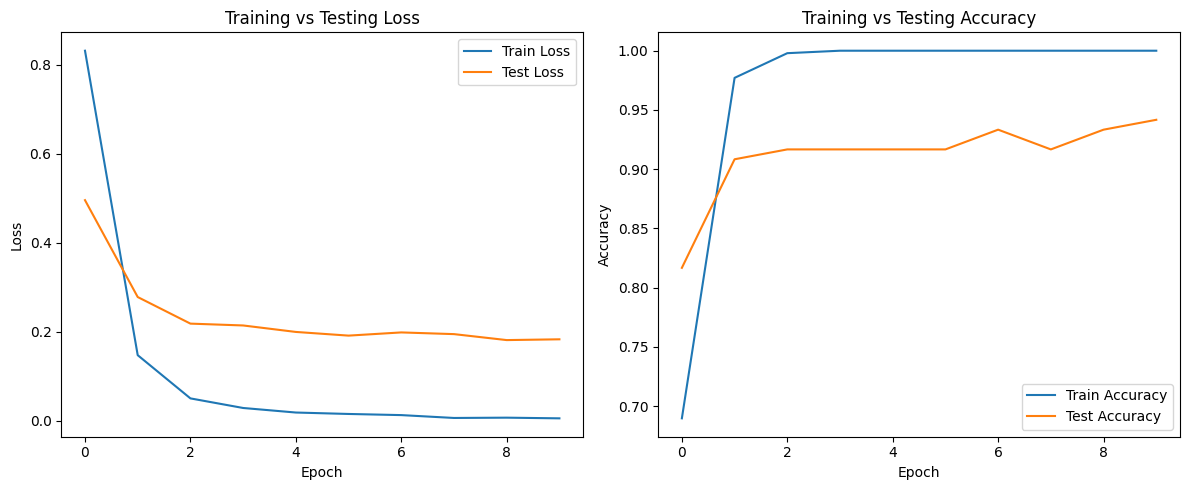

In [12]:
torch.manual_seed(123)

# Test the model with a random batch (optional)
rand_input = torch.randn((32, 3, 256, 256))
rand_out = model(rand_input)
print(rand_out.shape)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

# Move model to GPU (if available)
model.to(device)

# Prepare a loss function
loss_func = nn.CrossEntropyLoss()

# Create new optimizer instance
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # Lower learning rate is more suitable for transfer learning

# Define total number of epochs
num_epochs = 10

# Calculate the initial model loss and accuracy
test_loss, test_acc = test(model, loss_func, test_loader, device)
print(f"Pretrained model test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

# Prepare lists for accuracies and losses tracking
all_train_losses = []
all_train_acc = []
all_test_losses = []
all_test_acc = []

# Start training
for epoch in range(num_epochs):
    preds = []
    losses = []
    gt = []

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = loss_func(logits, labels)
        loss.backward()
        optimizer.step()

        p = torch.argmax(logits, dim=1)
        preds.extend(p.cpu().numpy())
        losses.append(loss.item())
        gt.extend(labels.detach().cpu().numpy())

    test_loss, test_acc = test(model, loss_func, test_loader, device)
    train_loss = sum(losses) / len(losses)
    train_acc = accuracy_score(gt, preds)

    print(f"Epoch: {epoch}, train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

    all_train_losses.append(train_loss)
    all_train_acc.append(train_acc)
    all_test_losses.append(test_loss)
    all_test_acc.append(test_acc)

epochs = list(range(len(all_train_losses)))

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
sns.lineplot(x=epochs, y=all_train_losses, label='Train Loss')
sns.lineplot(x=epochs, y=all_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Testing Loss')

# Accuracy plot
plt.subplot(1, 2, 2)
sns.lineplot(x=epochs, y=all_train_acc, label='Train Accuracy')
sns.lineplot(x=epochs, y=all_test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')

plt.tight_layout()
plt.show()

#### Freeze the pretrained model, train only the classifier head

Using device: mps
Pretrained model test accuracy: 0.2167, test loss: 1.7549
Epoch: 0, train loss: 1.6488, train acc: 0.2729, test loss: 1.5663, test_acc: 0.3000
Epoch: 1, train loss: 1.4968, train acc: 0.3479, test loss: 1.5048, test_acc: 0.3167
Epoch: 2, train loss: 1.4409, train acc: 0.3667, test loss: 1.4532, test_acc: 0.3667
Epoch: 3, train loss: 1.3892, train acc: 0.4604, test loss: 1.3921, test_acc: 0.4167
Epoch: 4, train loss: 1.3100, train acc: 0.5208, test loss: 1.3336, test_acc: 0.4417
Epoch: 5, train loss: 1.2481, train acc: 0.5917, test loss: 1.2818, test_acc: 0.5083
Epoch: 6, train loss: 1.1884, train acc: 0.6146, test loss: 1.2352, test_acc: 0.5333
Epoch: 7, train loss: 1.1465, train acc: 0.6375, test loss: 1.1925, test_acc: 0.5833
Epoch: 8, train loss: 1.0956, train acc: 0.6937, test loss: 1.1526, test_acc: 0.6333
Epoch: 9, train loss: 1.0549, train acc: 0.7021, test loss: 1.1210, test_acc: 0.6250
Epoch: 10, train loss: 0.9927, train acc: 0.7542, test loss: 1.0814, test_

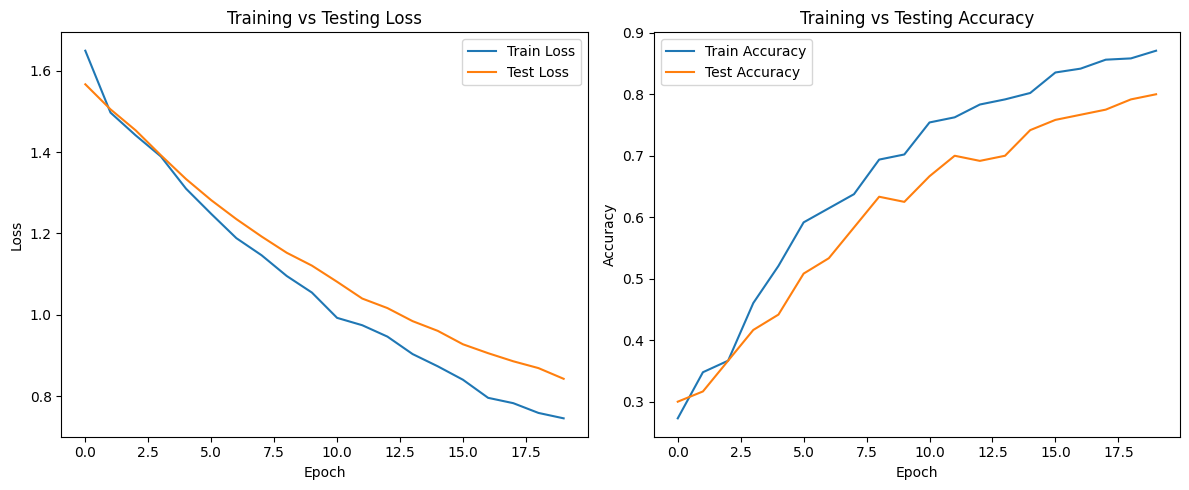

In [13]:
torch.manual_seed(123)

# Initialize a new pretrained model
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Freeze all parameters
for param in model.parameters():
    param.requires_grad = False

head_in_features = model.fc.in_features
model.fc = nn.Linear(head_in_features, num_classes)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

model.to(device)

# Prepare a loss function
loss_func = nn.CrossEntropyLoss()

# Create new optimizer instance
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # Lower learning rate is more suitable for transfer learning

# Define total number of epochs
num_epochs = 20

# Calculate the initial model loss and accuracy
test_loss, test_acc = test(model, loss_func, test_loader, device)
print(f"Pretrained model test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

# Prepare lists for accuracies and losses tracking
all_train_losses = []
all_train_acc = []
all_test_losses = []
all_test_acc = []

# Start training
for epoch in range(num_epochs):
    preds = []
    losses = []
    gt = []

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)
        loss = loss_func(logits, labels)
        loss.backward()
        optimizer.step()

        p = torch.argmax(logits, dim=1)
        preds.extend(p.cpu().numpy())
        losses.append(loss.item())
        gt.extend(labels.detach().cpu().numpy())

    test_loss, test_acc = test(model, loss_func, test_loader, device)
    train_loss = sum(losses) / len(losses)
    train_acc = accuracy_score(gt, preds)

    print(f"Epoch: {epoch}, train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, test loss: {test_loss:.4f}, test_acc: {test_acc:.4f}")

    all_train_losses.append(train_loss)
    all_train_acc.append(train_acc)
    all_test_losses.append(test_loss)
    all_test_acc.append(test_acc)

epochs = list(range(len(all_train_losses)))

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
sns.lineplot(x=epochs, y=all_train_losses, label='Train Loss')
sns.lineplot(x=epochs, y=all_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Testing Loss')

# Accuracy plot
plt.subplot(1, 2, 2)
sns.lineplot(x=epochs, y=all_train_acc, label='Train Accuracy')
sns.lineplot(x=epochs, y=all_test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')

plt.tight_layout()
plt.show()


### Test model predictions

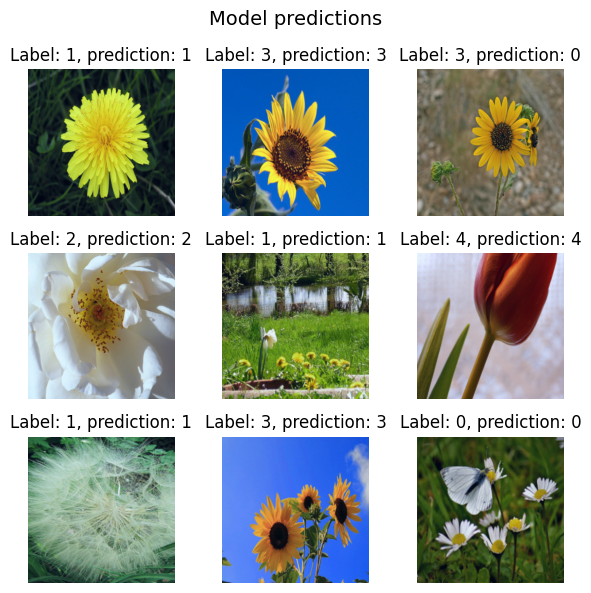

In [14]:
model.eval()

# Model predictions
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
fig.suptitle("Model predictions", fontsize=14)

for i in range(9):
    image, label = test_dataset[i]
    image = image.to(device)

    pred_prob = model(image.unsqueeze(0))
    pred_class = torch.argmax(pred_prob, dim=1)

    image = image.cpu().squeeze().permute(1, 2, 0).numpy()

    # Normalize to 0-1 range (this is optional and offers better visualization, pyplot expects the 0-1 range for float dtypes)
    image = image - np.min(image)
    image = image / np.max(image)

    ax = axes[i // 3, i % 3]
    ax.imshow(image)
    ax.set_title(f"Label: {label}, prediction: {pred_class.cpu().numpy()[0]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Exercises



1. Experiment with different training image transforms (e.g.: rotations, noise, etc.)
2. Set the dropout to 50%
3. Modify the network layers
4. Save the trained model weights
5. Experiment with different optimizers
6. Add batch normalization to the custom CNN and the fully connected models